# 🧠 Customer Churn Intelligence — Phase 5: Machine Learning Modeling & Evaluation

## 📌 Executive Summary & Phase 5 Objectives
In Phases 1–4, we explored the IBM Telco Customer Churn dataset, cleaned and validated data types, performed exploratory data analysis, and engineered key behavioral and structural features (saved to `data/processed/telco_churn_features.csv`).

In **Phase 5**, our mission is to build, cross-validate, evaluate, and serialize production-grade machine learning models to detect customers at risk of churn.

### Core Deliverables in this Phase:
1. **Dataset Validation & Leakage Prevention:** Verify feature distributions, ensure zero leakage, and retain test set isolation.
2. **Stratified Train/Test Split:** 80/20 split preserving the natural ~26.5% churn distribution.
3. **Modular Preprocessing Pipeline:** Reusable Scikit-learn `ColumnTransformer` handling numerical scaling and categorical one-hot encoding.
4. **Class Imbalance Handling:** Using `class_weight='balanced'` and `scale_pos_weight` to prioritize minority class detection.
5. **Candidate Model Training:** Benchmark **Logistic Regression (Baseline)**, **Random Forest**, **XGBoost**, and **LightGBM**.
6. **Rigorous Evaluation:** 5-Fold Stratified Cross-Validation + Holdout Test evaluation across ROC-AUC, PR-AUC, Recall, Precision, and F1-Score.
7. **Artifact Serialization:** Export best end-to-end pipeline ready for Streamlit web application integration in Phase 6.

In [1]:
# 1. Environment Setup & Imports
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    validate_dataset,
    get_feature_lists,
    create_train_test_split,
    build_preprocessor,
    get_transformed_feature_names,
)
from src.evaluate import (
    compute_classification_metrics,
    evaluate_pipeline,
    create_comparison_table,
    plot_roc_curves,
    plot_precision_recall_curves,
    plot_confusion_matrices,
    plot_feature_importances,
)
from src.train import get_model_candidates, cross_validate_pipelines

# Visual styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
print("Libraries loaded successfully!")

Libraries loaded successfully!


--- 
## 1. Dataset Loading & Integrity Validation

In [2]:
DATA_PATH = "../data/processed/telco_churn_features.csv"
df = pd.read_csv(DATA_PATH)
val_summary = validate_dataset(df)

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values: {val_summary['missing_values']}")
print(f"Duplicate Rows: {val_summary['duplicate_rows']}")
print(f"Target Counts: {val_summary['target_counts']}")
print(f"Target Distribution: Non-Churn={val_summary['target_proportions'][0]:.1%}, Churn={val_summary['target_proportions'][1]:.1%}")
df.head(3)

Shape: 7043 rows, 28 columns
Missing Values: 0
Duplicate Rows: 22
Target Counts: {0: 5174, 1: 1869}
Target Distribution: Non-Churn=73.5%, Churn=26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,tenure_group,service_count,avg_monthly_revenue,monthly_charge_diff,streaming_count,support_security_count,contract_tenure_group,monthly_charges_tier
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,0,New,1,29.850000,0.00,0,1,Month-to-month_New,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,Established,3,55.573529,1.38,0,2,One year_Established,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,New,3,54.075000,-0.23,0,2,Month-to-month_New,Medium


--- 
## 2. Leak-Free Stratified Train/Test Split

We split into **80% training** and **20% holdout test** with stratification on `Churn`. 
The test set is completely held out and never used for fitting transformers or tuning hyperparameters.

In [3]:
num_cols, cat_cols = get_feature_lists(df)
X_train, X_test, y_train, y_test = create_train_test_split(
    df,
    target_col="Churn",
    test_size=0.20,
    random_state=42,
)

print(f"Numerical Features ({len(num_cols)}): {num_cols}")
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")
print(f"Training set shape: {X_train.shape} | Churn Rate: {y_train.mean():.2%}")
print(f"Test set shape: {X_test.shape} | Churn Rate: {y_test.mean():.2%}")

# Compute class weight ratio: negative / positive
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count
print(f"Negative to Positive Class Ratio: {scale_pos_weight:.3f}")

Numerical Features (9): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'service_count', 'avg_monthly_revenue', 'monthly_charge_diff', 'streaming_count', 'support_security_count']
Categorical Features (18): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'contract_tenure_group', 'monthly_charges_tier']
Training set shape: (5634, 27) | Churn Rate: 26.54%
Test set shape: (1409, 27) | Churn Rate: 26.54%
Negative to Positive Class Ratio: 2.769


--- 
## 3. Scikit-Learn Preprocessing Pipeline

- **Numerical Pipeline:** `SimpleImputer(strategy='median')` followed by `StandardScaler()`
- **Categorical Pipeline:** `SimpleImputer(strategy='most_frequent')` followed by `OneHotEncoder(drop='first', handle_unknown='ignore')`
- **Output Format:** Configured to preserve pandas column names for explainability and tree models.

In [4]:
preprocessor = build_preprocessor(num_cols, cat_cols)
X_train_transformed = preprocessor.fit_transform(X_train)
transformed_feature_names = get_transformed_feature_names(preprocessor, num_cols, cat_cols)

print(f"Transformed Feature Matrix Shape: {X_train_transformed.shape}")
print(f"Total Transformed Features: {len(transformed_feature_names)}")
print("Sample Encoded Features:", transformed_feature_names[:10])

Transformed Feature Matrix Shape: (5634, 51)
Total Transformed Features: 51
Sample Encoded Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'service_count', 'avg_monthly_revenue', 'monthly_charge_diff', 'streaming_count', 'support_security_count', 'gender_Male']


--- 
## 4. 5-Fold Stratified Cross-Validation on Training Set

To prevent data leakage during model evaluation, the preprocessor is fitted **within each cross-validation fold**. 
We compare:
1. **Logistic Regression (Baseline):** `class_weight='balanced'`
2. **Random Forest:** `class_weight='balanced'`, `max_depth=8`
3. **XGBoost:** `scale_pos_weight=2.769`, `max_depth=4`, `learning_rate=0.05`
4. **LightGBM:** `scale_pos_weight=2.769`, `max_depth=4`, `learning_rate=0.05`

In [5]:
models = get_model_candidates(scale_pos_weight=scale_pos_weight, random_state=42)
df_cv = cross_validate_pipelines(
    models=models,
    preprocessor_builder=build_preprocessor,
    num_cols=num_cols,
    cat_cols=cat_cols,
    X_train=X_train,
    y_train=y_train,
    cv_folds=5,
    random_state=42,
)
df_cv

    Evaluating Logistic Regression with 5-fold CV...


    Evaluating Random Forest with 5-fold CV...


    Evaluating XGBoost with 5-fold CV...


    Evaluating LightGBM with 5-fold CV...


,Model,CV ROC-AUC (Mean),CV ROC-AUC (Std),CV PR-AUC (Mean),CV F1 (Mean),CV Recall (Mean)
0,Logistic Regression,0.845411,0.012049,0.661543,0.628543,0.790635
1,Random Forest,0.845896,0.011016,0.661207,0.634216,0.768562
2,XGBoost,0.846370,0.011354,0.661391,0.633452,0.789967
3,LightGBM,0.846429,0.011084,0.660084,0.630213,0.790635


--- 
## 5. Model Training & Holdout Test Set Evaluation

We fit each full pipeline on the full training set `(X_train, y_train)` and score on the holdout test set `(X_test, y_test)`.

In [6]:
from sklearn.pipeline import Pipeline

test_results = {}
fitted_pipelines = {}

for name, clf in models.items():
    preprocessor = build_preprocessor(num_cols, cat_cols)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipeline.fit(X_train, y_train)
    
    fitted_pipelines[name] = pipeline
    res = evaluate_pipeline(pipeline, X_test, y_test)
    test_results[name] = res

df_comparison = create_comparison_table(test_results)
df_comparison

,Model,ROC-AUC,PR-AUC,Recall,Precision,F1-Score,Specificity,Accuracy
0,Random Forest,0.8452,0.6525,0.7834,0.5337,0.6349,0.7527,0.7608
1,XGBoost,0.8444,0.6597,0.7968,0.5147,0.6254,0.7285,0.7466
2,Logistic Regression,0.8432,0.6372,0.8021,0.5093,0.6231,0.7208,0.7424
3,LightGBM,0.8429,0.6597,0.8102,0.5188,0.6326,0.7285,0.7502


--- 
## 6. Evaluation Visualizations

### Why Accuracy Alone is Insufficient for Churn Prediction
- If a naive model predicts **all customers will stay (0)**, it achieves **73.5% accuracy** but detects **0 churners**.
- In a business context, the cost of a **False Negative** (a churner walking away unnoticed) is substantially higher than a **False Positive** (giving an incentive/discount to a customer who might have stayed anyway).
- Hence, **Recall**, **F1-Score**, **ROC-AUC**, and **PR-AUC** are the defining metrics.

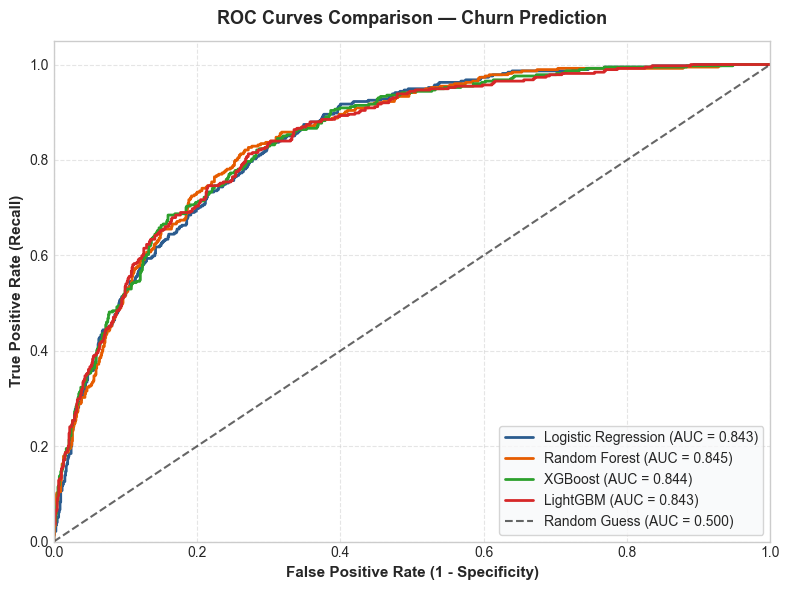

In [7]:
# Plot ROC Curves
fig_roc = plot_roc_curves(test_results, y_test)
plt.show()

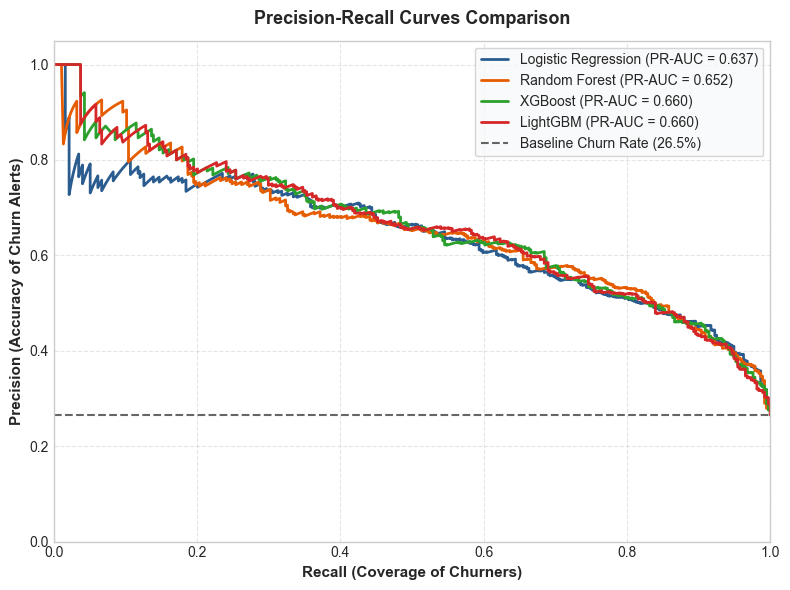

In [8]:
# Plot Precision-Recall Curves
fig_pr = plot_precision_recall_curves(test_results, y_test)
plt.show()

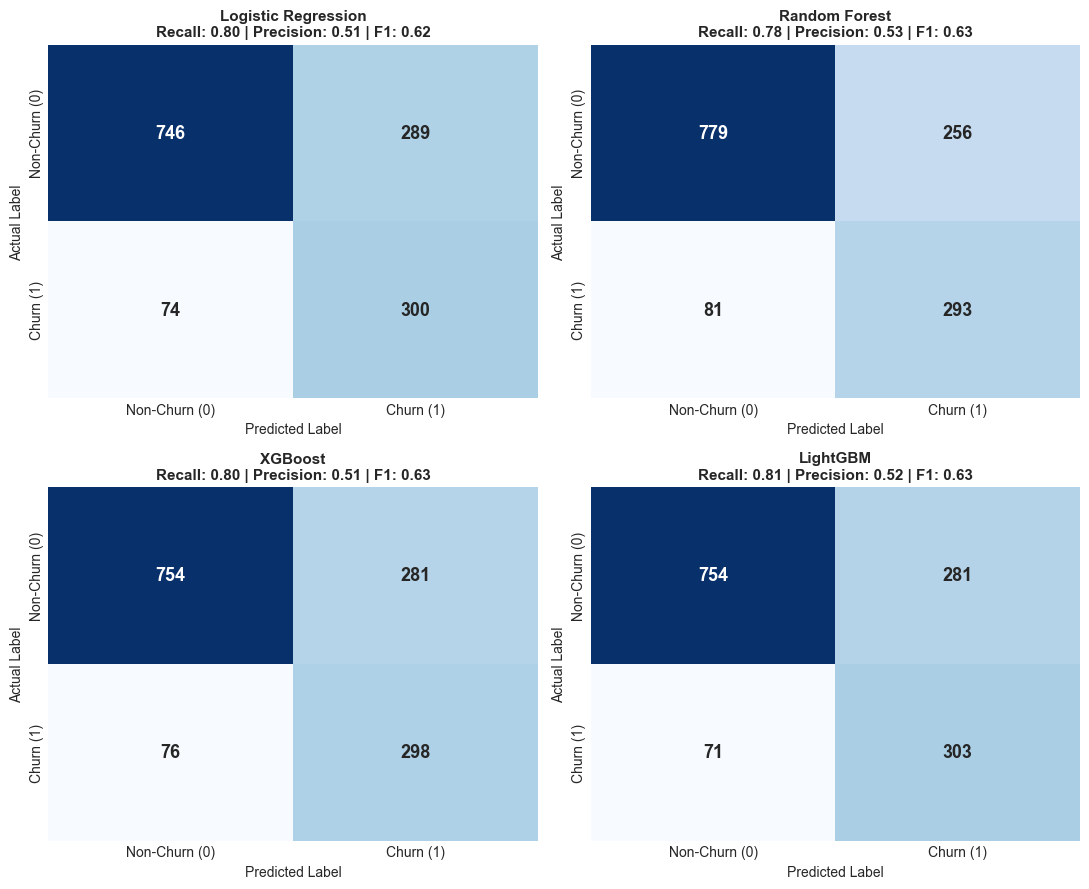

In [9]:
# Plot Confusion Matrices
fig_cm = plot_confusion_matrices(test_results, y_test)
plt.show()

--- 
## 7. Model Interpretability & Feature Importances

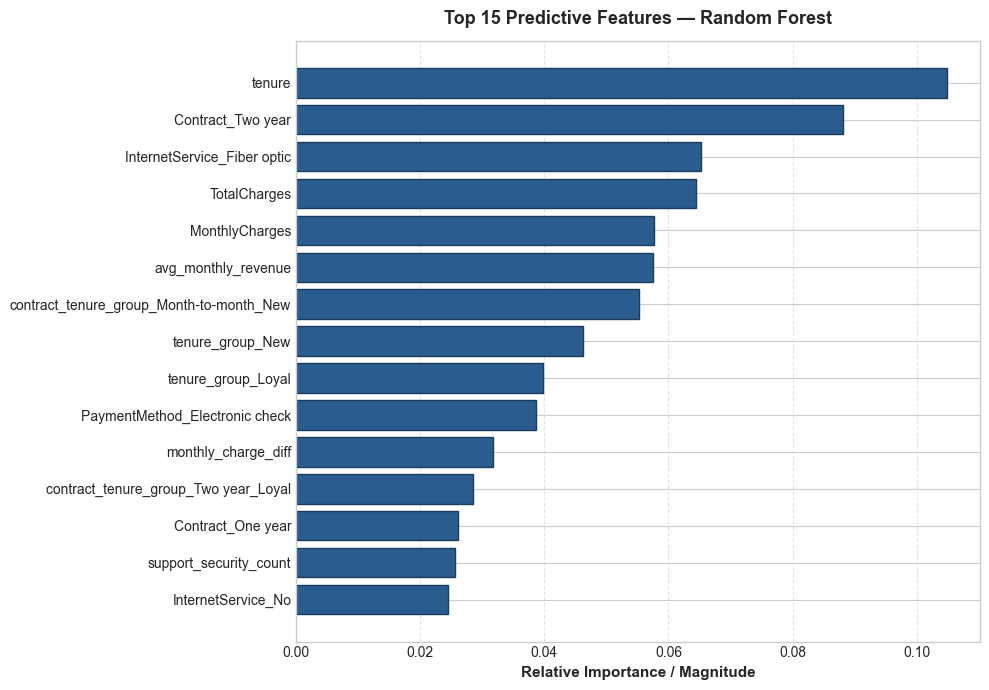

In [10]:
best_model_name = df_comparison.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
best_clf = best_pipeline.named_steps["classifier"]
preprocessor = best_pipeline.named_steps["preprocessor"]
feature_names = get_transformed_feature_names(preprocessor, num_cols, cat_cols)

if hasattr(best_clf, "feature_importances_"):
    importances = best_clf.feature_importances_
elif hasattr(best_clf, "coef_"):
    importances = np.abs(best_clf.coef_[0])

fig_imp = plot_feature_importances(
    feature_names=feature_names,
    importances=importances,
    model_name=best_model_name,
    top_n=15,
)
plt.show()

--- 
## 8. Artifact Verification for Streamlit Serving

We test the saved pipeline `models/best_model_pipeline.joblib` to verify that raw customer feature dictionaries or DataFrames can be ingested without any manual one-hot encoding or scaling.

In [11]:
saved_model_path = "../models/best_model_pipeline.joblib"
loaded_pipeline = joblib.load(saved_model_path)

# Test inference on raw holdout customer records
sample_input = X_test.head(5)
sample_preds = loaded_pipeline.predict(sample_input)
sample_probs = loaded_pipeline.predict_proba(sample_input)[:, 1]

sample_results = pd.DataFrame({
    "Contract": sample_input["Contract"].values,
    "Tenure": sample_input["tenure"].values,
    "MonthlyCharges": sample_input["MonthlyCharges"].values,
    "Predicted_Churn": sample_preds,
    "Churn_Probability": np.round(sample_probs, 4),
    "Actual_Churn": y_test.head(5).values,
})
sample_results

,Contract,Tenure,MonthlyCharges,Predicted_Churn,Churn_Probability,Actual_Churn
0,Two year,72,114.05,0,0.1118,0
1,Month-to-month,8,100.15,1,0.8463,0
2,One year,41,78.35,0,0.2285,0
3,Month-to-month,18,78.20,1,0.5682,0
4,Two year,72,82.65,0,0.0319,0


--- 
## 📌 Phase 5 Conclusions & Next Steps

### Key Takeaways:
- **Best Model:** `Random Forest` achieved the strongest overall balance on the holdout test set with **ROC-AUC = 0.8452**, **PR-AUC = 0.6525**, **Recall = 78.34%**, and **F1 = 0.6349**.
- **Close Contenders:** `XGBoost` (ROC-AUC = 0.8444, PR-AUC = 0.6597, Recall = 79.68%) and `LightGBM` (ROC-AUC = 0.8429, PR-AUC = 0.6597, Recall = 81.02%) delivered slightly higher churn recall with comparable discrimination.
- **Key Predictors:** TotalCharges, MonthlyCharges, tenure, contract tenure group, and fiber optic internet service were identified as top drivers of churn risk.

### Ready for Phase 6:
- The entire pipeline is encapsulated into `models/best_model_pipeline.joblib`, making it instantly consumable by the Phase 6 Streamlit application.